<a href="https://colab.research.google.com/github/anupamchaudhary-rgb/Workshoppython/blob/main/Experiment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total components = 12
Number of nuts = 6
Number of bolts = 6
Binary image:


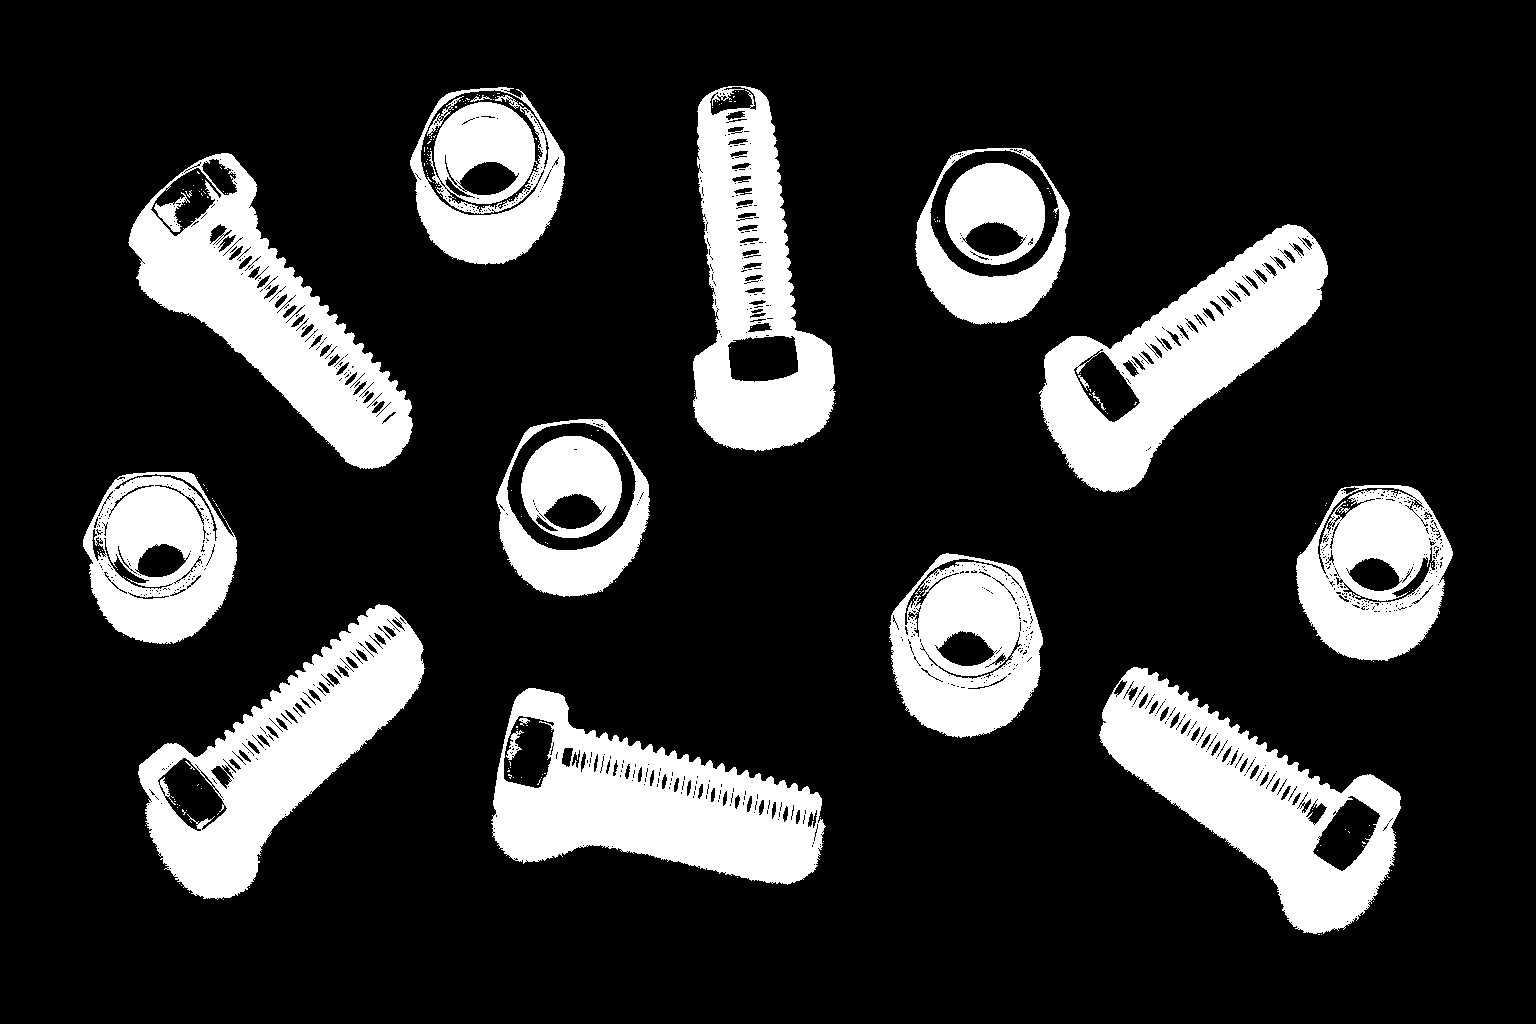

Classification result:


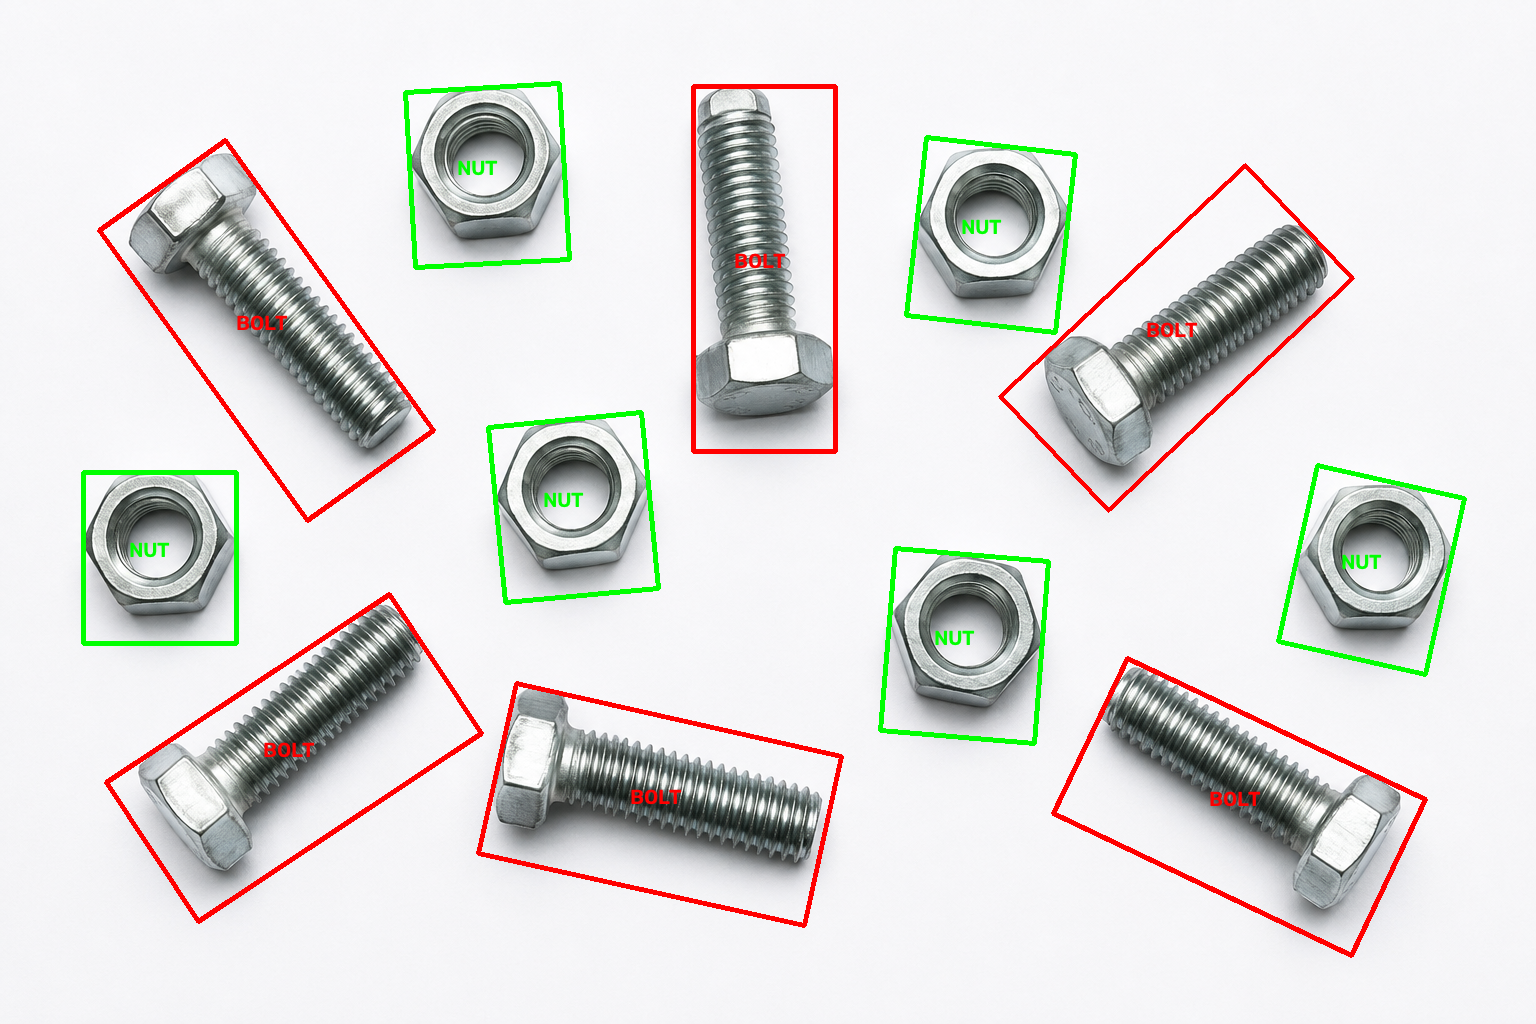

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the image
image = cv2.imread("nuts_bolts.png")

# Check whether the image was loaded
if image is None:
    print("Image not found. Please upload nuts_bolts.png")

else:
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Convert grayscale image into black and white
    _, binary = cv2.threshold(
        gray,
        220,
        255,
        cv2.THRESH_BINARY_INV
    )

    # Find only the outer contours
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    nut_count = 0
    bolt_count = 0

    # Check every detected object
    for contour in contours:

        area = cv2.contourArea(contour)

        # Ignore small unwanted objects
        if area > 2000:

            # Find a rotated rectangle around the object
            rectangle = cv2.minAreaRect(contour)

            # Get centre, width, height and angle
            centre, size, angle = rectangle
            width, height = size

            # Avoid division by zero
            if width == 0 or height == 0:
                continue

            # Calculate orientation-independent aspect ratio
            long_side = max(width, height)
            short_side = min(width, height)

            aspect_ratio = long_side / short_side

            # Classify the object
            if aspect_ratio < 1.7:

                nut_count = nut_count + 1
                text = "NUT"
                colour = (0, 255, 0)

            else:

                bolt_count = bolt_count + 1
                text = "BOLT"
                colour = (0, 0, 255)

            # Obtain four corner points of rotated rectangle
            box = cv2.boxPoints(rectangle)
            box = np.int32(box)

            # Draw the rotated rectangle
            cv2.drawContours(
                image,
                [box],
                0,
                colour,
                3
            )

            # Select a position for writing the label
            x = int(centre[0])
            y = int(centre[1])

            # Write NUT or BOLT
            cv2.putText(
                image,
                text,
                (x - 30, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                colour,
                2
            )

    # Calculate total number of components
    total_components = nut_count + bolt_count

    # Print the results
    print("Total components =", total_components)
    print("Number of nuts =", nut_count)
    print("Number of bolts =", bolt_count)

    # Display the binary image
    print("Binary image:")
    cv2_imshow(binary)

    # Display the classified image
    print("Classification result:")
    cv2_imshow(image)

    # Save the result
    cv2.imwrite("nuts_bolts_result.png", image)